/tmp/ipykernel_25168/2665794237.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


=== FASE 1: RAIO-X INICIAL ===
Linhas Originais: 20400 | Colunas Originais: 34


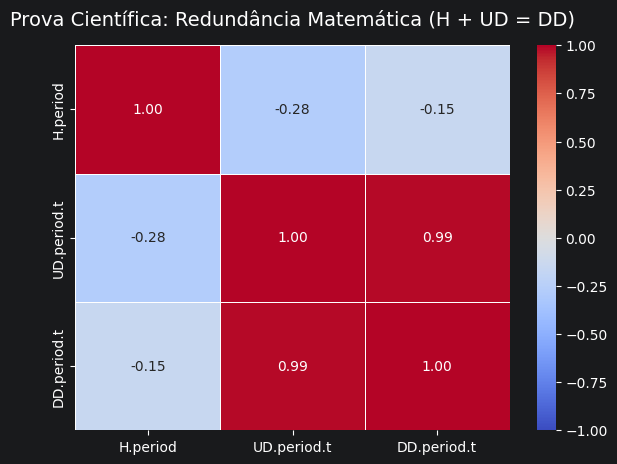


=== FASE 2 CONCLUÍDA ===
Colunas Redundantes removidas. O 'sessionIndex' foi preservado.
Shape Atual: 20400 Linhas | 23 Colunas


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/DSL-StrongPasswordData.csv')
print("=== FASE 1: RAIO-X INICIAL ===")
print(f"Linhas Originais: {df.shape[0]} | Colunas Originais: {df.shape[1]}")

subset_teste = df[['H.period', 'UD.period.t', 'DD.period.t']]
correlacao = subset_teste.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Prova Científica: Redundância Matemática (H + UD = DD)", fontsize=14, pad=15)
plt.show()

df_limpo = df.drop(['rep'], axis=1)

colunas_dd = [col for col in df_limpo.columns if 'DD' in col]
df_limpo = df_limpo.drop(colunas_dd, axis=1)

print(f"\n=== FASE 2 CONCLUÍDA ===")
print(f"Colunas Redundantes removidas. O 'sessionIndex' foi preservado.")
print(f"Shape Atual: {df_limpo.shape[0]} Linhas | {df_limpo.shape[1]} Colunas")

/tmp/ipykernel_25168/526077242.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sem_outliers = df_limpo.groupby('subject', group_keys=False).apply(remover_outliers_locais).reset_index(drop=True)


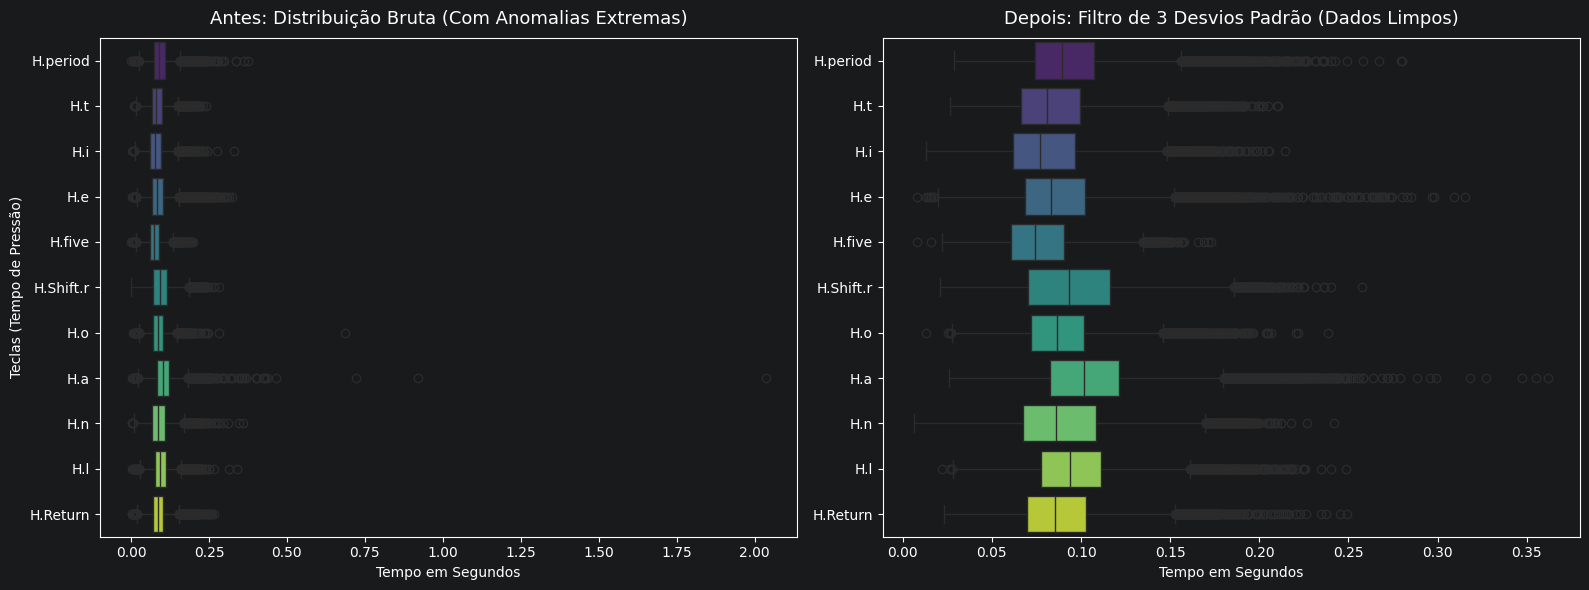

=== FASE 3: OUTLIERS LOCAIS REMOVIDOS ===
Linhas originais: 20400 | Linhas mantidas: 15848
Anomalias reais descartadas: 4552 (Ruído motor extremo limpo com rigor científico)


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

features_temporais = [col for col in df_limpo.columns if col not in ['subject', 'sessionIndex']]
colunas_h = [col for col in df_limpo.columns if 'H.' in col]

def remover_outliers_locais(grupo):
    dados_temporais = grupo[features_temporais]
    z_scores = ((dados_temporais - dados_temporais.mean()) / dados_temporais.std()).abs()
    mascara = (z_scores < 3).all(axis=1)
    return grupo[mascara]

df_sem_outliers = df_limpo.groupby('subject', group_keys=False).apply(remover_outliers_locais).reset_index(drop=True)
linhas_removidas = df_limpo.shape[0] - df_sem_outliers.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_limpo[colunas_h], orient='h', palette='viridis', ax=axes[0])
axes[0].set_title("Antes: Distribuição Bruta (Com Anomalias Extremas)", fontsize=13, pad=10)
axes[0].set_xlabel("Tempo em Segundos")
axes[0].set_ylabel("Teclas (Tempo de Pressão)")

sns.boxplot(data=df_sem_outliers[colunas_h], orient='h', palette='viridis', ax=axes[1])
axes[1].set_title("Depois: Filtro de 3 Desvios Padrão (Dados Limpos)", fontsize=13, pad=10)
axes[1].set_xlabel("Tempo em Segundos")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("=== FASE 3: OUTLIERS LOCAIS REMOVIDOS ===")
print(f"Linhas originais: {df_limpo.shape[0]} | Linhas mantidas: {df_sem_outliers.shape[0]}")
print(f"Anomalias reais descartadas: {linhas_removidas} (Ruído motor extremo limpo com rigor científico)")

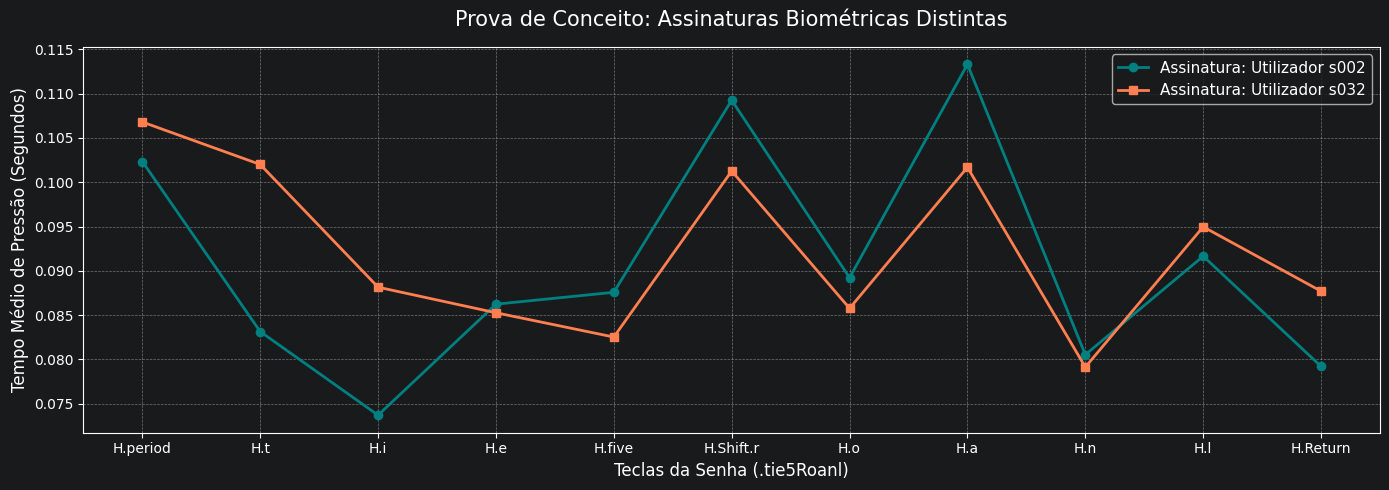

In [3]:
plt.figure(figsize=(14, 5))

ritmo_user1 = df_sem_outliers[df_sem_outliers['subject'] == 's002'][colunas_h].mean()
ritmo_user2 = df_sem_outliers[df_sem_outliers['subject'] == 's032'][colunas_h].mean()

plt.plot(colunas_h, ritmo_user1, marker='o', linewidth=2, label='Assinatura: Utilizador s002', color='teal')
plt.plot(colunas_h, ritmo_user2, marker='s', linewidth=2, label='Assinatura: Utilizador s032', color='coral')

plt.title("Prova de Conceito: Assinaturas Biométricas Distintas", fontsize=15, pad=15)
plt.xlabel("Teclas da Senha (.tie5Roanl)", fontsize=12)
plt.ylabel("Tempo Médio de Pressão (Segundos)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [4]:
import os

df_train_bruto = df_sem_outliers[df_sem_outliers['sessionIndex'] <= 6].copy()

df_test_bruto = df_sem_outliers[df_sem_outliers['sessionIndex'] >= 7].copy()

df_train_bruto = df_train_bruto.drop(['sessionIndex'], axis=1)
df_test_bruto = df_test_bruto.drop(['sessionIndex'], axis=1)

print("=== FASE 4: SPLIT TEMPORAL EXECUTADO ===")
print(f"Amostras de Treino (Sessões 1-6): {df_train_bruto.shape[0]}")
print(f"Amostras de Teste Cego (Sessões 7-8): {df_test_bruto.shape[0]}")

=== FASE 4: SPLIT TEMPORAL EXECUTADO ===
Amostras de Treino (Sessões 1-6): 11686
Amostras de Teste Cego (Sessões 7-8): 4162


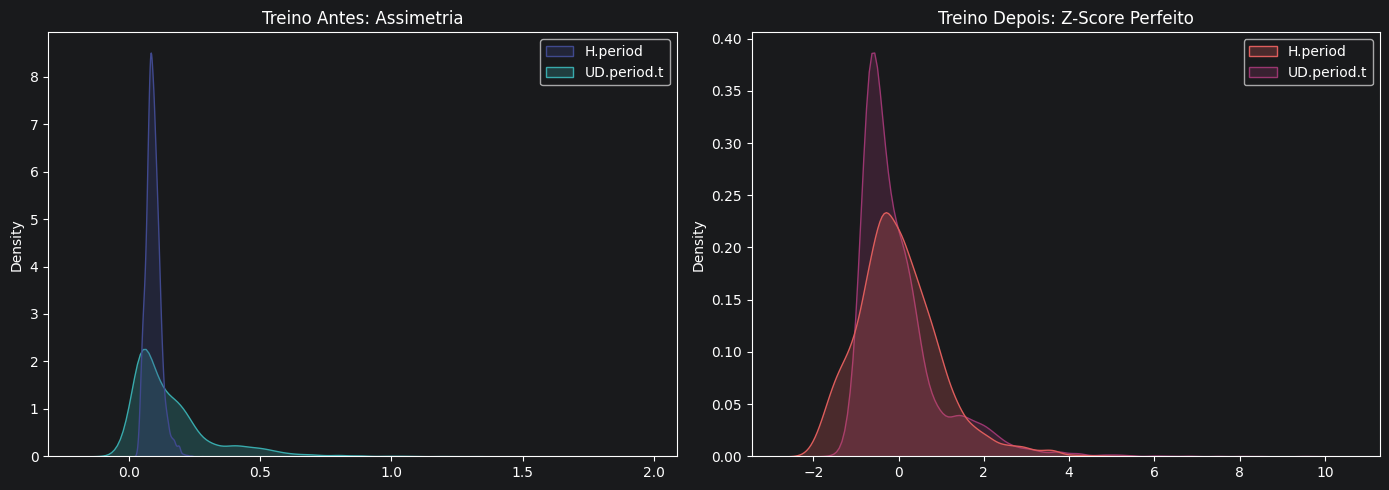

=== FASE 5: NORMALIZAÇÃO SEGURA CONCLUÍDA ===
Os dados foram exportados para a pasta 'data/'.


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = df_train_bruto.columns.drop('subject')

X_train_scaled = scaler.fit_transform(df_train_bruto[features])
df_train_final = pd.DataFrame(X_train_scaled, columns=features)
df_train_final['subject'] = df_train_bruto['subject'].values

X_test_scaled = scaler.transform(df_test_bruto[features])
df_test_final = pd.DataFrame(X_test_scaled, columns=features)
df_test_final['subject'] = df_test_bruto['subject'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=df_train_bruto[['H.period', 'UD.period.t']], ax=axes[0], fill=True, palette="mako")
axes[0].set_title("Treino Antes: Assimetria", fontsize=12)
sns.kdeplot(data=df_train_final[['H.period', 'UD.period.t']], ax=axes[1], fill=True, palette="flare")
axes[1].set_title("Treino Depois: Z-Score Perfeito", fontsize=12)
plt.tight_layout()
plt.show()

os.makedirs('../data', exist_ok=True)
df_train_final.to_csv('../data/train_keystroke.csv', index=False)
df_test_final.to_csv('../data/test_keystroke.csv', index=False)

print("=== FASE 5: NORMALIZAÇÃO SEGURA CONCLUÍDA ===")
print("Os dados foram exportados para a pasta 'data/'.")

In [6]:
cols_hold = [c for c in df_train_bruto.columns if 'H.' in c]
cols_ud = [c for c in df_train_bruto.columns if 'UD.' in c]

global_hold_mean = df_train_bruto[cols_hold].values.mean()
global_hold_std = df_train_bruto[cols_hold].values.std()

global_flight_mean = df_train_bruto[cols_ud].values.mean()
global_flight_std = df_train_bruto[cols_ud].values.std()

print("=== CONSTANTES PARA O BACKEND ===")
print(f"GLOBAL_HOLD_MEAN = {global_hold_mean:.4f}")
print(f"GLOBAL_HOLD_STD = {global_hold_std:.4f}")
print(f"GLOBAL_FLIGHT_MEAN = {global_flight_mean:.4f}")
print(f"GLOBAL_FLIGHT_STD = {global_flight_std:.4f}")

=== CONSTANTES PARA O BACKEND ===
GLOBAL_HOLD_MEAN = 0.0891
GLOBAL_HOLD_STD = 0.0288
GLOBAL_FLIGHT_MEAN = 0.1494
GLOBAL_FLIGHT_STD = 0.1739
